In [ ]:
from utils import MedicalDataset, evaluate_model, train_transform, draw_img, repeat_samples, to_tensor, train_model
from scipy.ndimage import center_of_mass
import torch
import os
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
from torch import nn
from torchvision.models import resnet18, ResNet18_Weights
from torch.utils.data import DataLoader
from torch.optim import Adam

In [2]:
class AneurysmClassifier(nn.Module):

    def __init__(self, in_channels, num_classes):
        super().__init__()
        self.resnet = resnet18(weights=ResNet18_Weights.DEFAULT)

        for param in self.resnet.parameters():
            param.requires_grad = False

        for param in self.resnet.layer4.parameters():
            param.requires_grad = True

        orig_weights = self.resnet.conv1.weight.data
        self.resnet.conv1 = nn.Conv2d(in_channels, 64, kernel_size=7, stride=2, padding=3, bias=False)
        avg_weights = orig_weights.mean(dim=1, keepdim=True)
        self.resnet.conv1.weight.data = avg_weights.repeat(1, 10, 1, 1)

        self.resnet.conv1.weight.requires_grad = True

        self.resnet.fc = nn.Sequential(
            nn.Dropout(0.3),
            nn.Linear(self.resnet.fc.in_features, num_classes)
        )

    def forward(self, x):
        return self.resnet(x)


In [3]:
def scan_masks_sizes(segmentations):
    x_diff, y_diff = [], []
    max_x_dist = max_x_dist_idx = max_y_dist = max_y_dist_idx = 0
    curr_idx = -1

    for batch in range(segmentations.shape[0]):
        scanned = _scan_mask(segmentations[batch, :, :, :])
        curr_idx += 1
        
        if not scanned:
            continue

        x_diff.append(scanned[1] - scanned[0])
        y_diff.append(scanned[3] - scanned[2])

        if max_x_dist < x_diff[-1]:
            max_x_dist = x_diff[-1]
            max_x_dist_idx = curr_idx

        if max_y_dist < y_diff[-1]:
            max_y_dist = y_diff[-1]
            max_y_dist_idx = curr_idx

    return np.array(x_diff), np.array(y_diff), max_x_dist_idx, max_y_dist_idx

def delete_images_without_cow(x, y):
    keep = np.any(x[:, :, :, 5:] != 0, axis=(1, 2, 3))
    return x[keep], y[keep]

def _scan_mask(seg):
    mask = np.where(seg > 0)
    min_x = mask[1].min()
    max_x = mask[1].max()
    min_y = mask[0].min()
    max_y = mask[0].max()
    return min_x, max_x, min_y, max_y

def get_centroids(segmentations):
    labels = np.ones_like(segmentations).cumsum(axis=0)
    indices = np.arange(1, segmentations.shape[0] + 1)
    return center_of_mass(segmentations > 0, labels, indices)

def center_crop_to_fixed_size(data, HEIGHT_HALF, WIDTH_HALF):
    cropped_data = []
    centroids = get_centroids(data[:, :, :, 5:])

    for i, centroid in enumerate(centroids):
        y = round(centroid[1])
        x = round(centroid[2])

        max_y = y + HEIGHT_HALF
        max_x = x + WIDTH_HALF
        min_y = y - HEIGHT_HALF
        min_x = x - WIDTH_HALF

        after_x = max(0, max_x - data.shape[2])
        after_y = max(0, max_y - data.shape[1])
        before_x = max(0, -min_x)
        before_y = max(0, -min_y)

        sliced_arr = data[i, min_y + before_y : max_y, min_x + before_x : max_x, :]

        cropped_data.append(
            np.pad(
            sliced_arr,
            ((before_y, after_y), (before_x, after_x), (0, 0)),
            mode='constant'
            )
        )

    return cropped_data

In [4]:
train_folder = Path('C:/Users/dawid/OneDrive/Pulpit/aneurysm classifier/data/train')
test_folder = Path('C:/Users/dawid/OneDrive/Pulpit/aneurysm classifier/data/test')

In [5]:
x_train = np.load(os.path.join(train_folder, 'train_images.npy'))
y_train = np.load(os.path.join(train_folder, 'train_labels.npy'))
x_test = np.load(os.path.join(test_folder, 'test_images.npy'))
y_test = np.load(os.path.join(test_folder, 'test_labels.npy'))

In [6]:
x_train, y_train = delete_images_without_cow(x_train, y_train)

(81, 148, 107, 146)


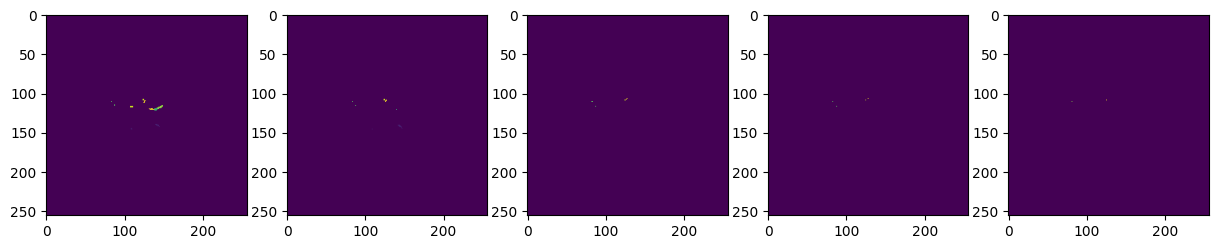

In [7]:
ret = _scan_mask(x_test[0, :, :, 5:])
print(ret)

fig, axes = plt.subplots(1, 5, figsize=(15, 10))

for i in range(5):
    axes[i].imshow(x_test[0, :, :, i + 5])

plt.show()

In [8]:
x_diff, y_diff, x_idx, y_idx = scan_masks_sizes(x_train[:, :, :, 5:])
xp_cut = x_diff[x_diff < np.percentile(x_diff, 98)].max()
yp_cut = y_diff[y_diff < np.percentile(y_diff, 98)].max()

print(f'Max\nX: {x_diff.max()}, Y: {y_diff.max()}')
print(f'Percetiles\nX: {xp_cut}, Y: {yp_cut}')

Max
X: 102, Y: 80
Percetiles
X: 92, Y: 55


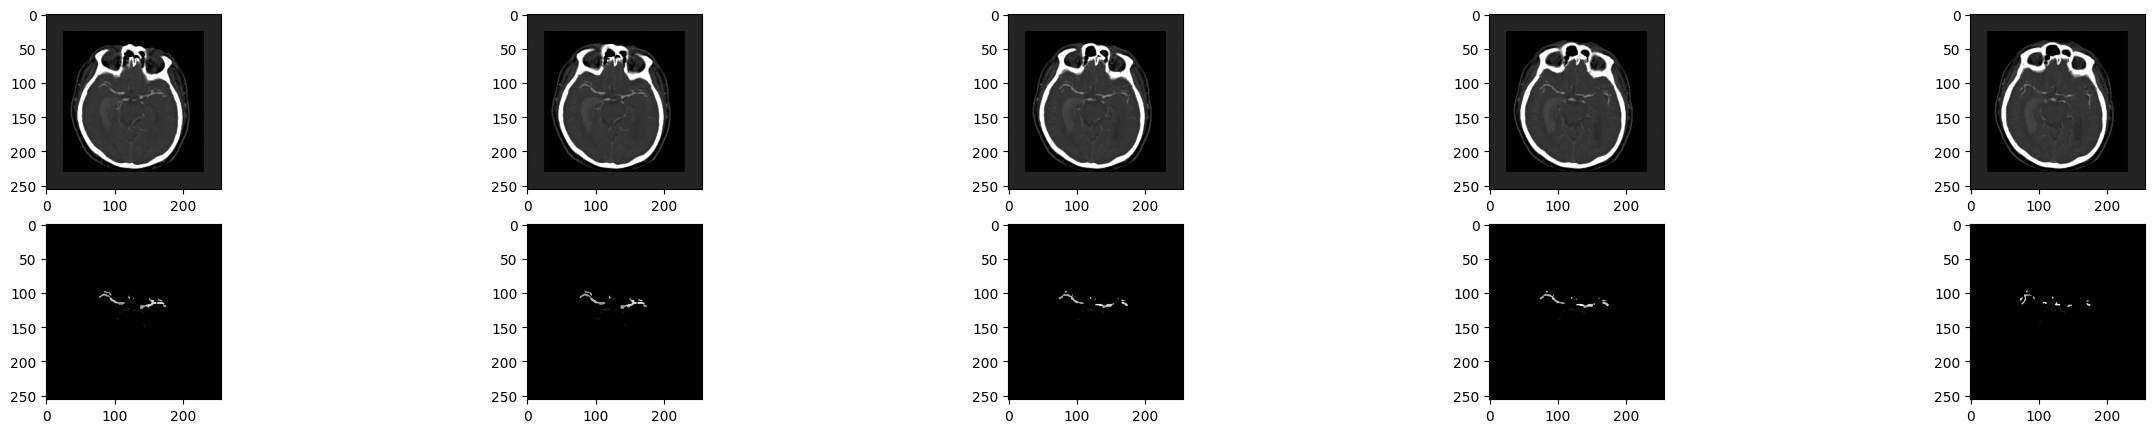

102 52
(73, 175, 97, 149)


In [9]:
draw_img(x_train[x_idx])
ret = _scan_mask(x_train[x_idx, :, :, 5:])
print(ret[1] - ret[0], ret[3] - ret[2])
print(ret)

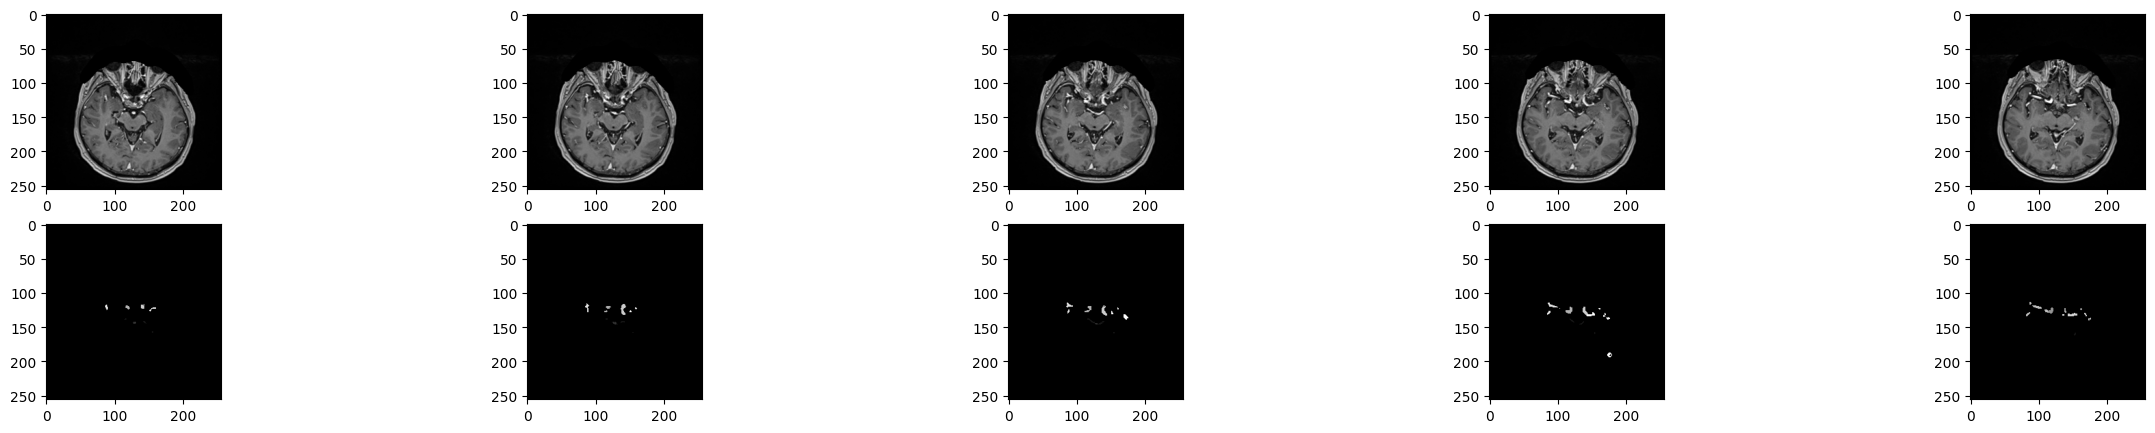

97 80
(82, 179, 114, 194)


In [10]:
draw_img(x_train[y_idx])
ret = _scan_mask(x_train[y_idx, :, :, 5:])
print(ret[1] - ret[0], ret[3] - ret[2])
print(ret)

In [11]:
WIDTH = 96
HEIGHT = 64
WIDTH_HALF = WIDTH // 2
HEIGHT_HALF = HEIGHT // 2

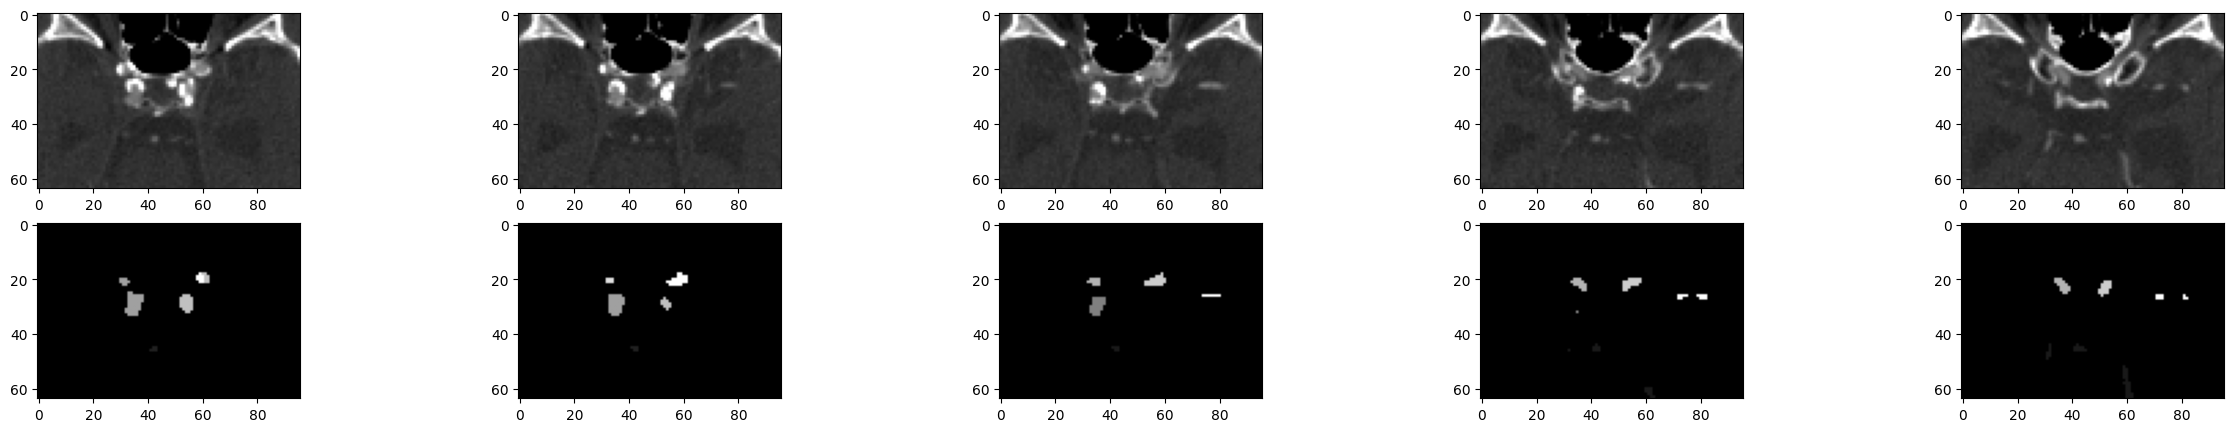

In [12]:
example = center_crop_to_fixed_size(x_train[0:2], HEIGHT_HALF, WIDTH_HALF)
draw_img(example[1])

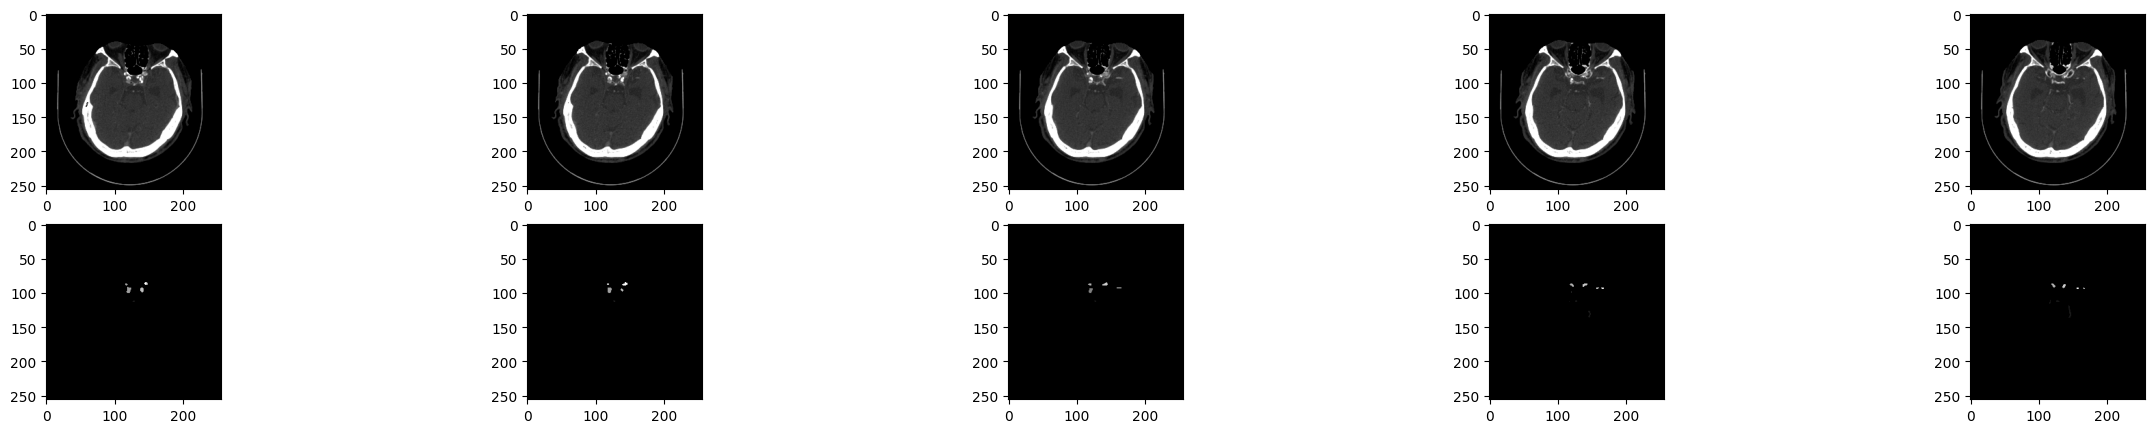

In [13]:
draw_img(x_train[1])

In [14]:
x_train, y_train = repeat_samples(x_train, y_train, 20)
x_train_tensor, y_train_tensor, x_test_tensor, y_test_tensor = to_tensor(x_train, y_train, x_test, y_test)

In [15]:
train_dataset = MedicalDataset(x_train_tensor, y_train_tensor, train_transform)
test_dataset = MedicalDataset(x_test_tensor, y_test_tensor)

batch_size = 32

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

In [16]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [22]:
lr = 1e-5
num_epochs = 8

model = AneurysmClassifier(10, 14)
model.to(device)

params = [p for p in model.parameters() if p.requires_grad]
optimizer = Adam(lr=lr, params=params)

class_weights = torch.tensor(
    [y_train.shape[0] / counts for counts in torch.bincount(y_train_tensor[:, 0])], dtype=torch.float32, device=device)
criterion = nn.CrossEntropyLoss(weight=class_weights)

In [ ]:
best_model_weights, history = train_model(
    model, optimizer, criterion, train_loader, test_loader, num_epochs, device)

Epoch: 1 / 8
Loss: 2.599107385284306, accuracy: 0.0903954802259887
Loss: 2.517584211223728, accuracy: 0.12087912087912088
New lowest loss. Epoch 1
Epoch: 2 / 8
Loss: 2.1017038971761703, accuracy: 0.25453464168896817
Loss: 2.4610831082522213, accuracy: 0.13186813186813187
New lowest loss. Epoch 2
Epoch: 3 / 8
Loss: 1.7585686347756115, accuracy: 0.40440083258994947
Loss: 2.4024240237015944, accuracy: 0.16483516483516483
New lowest loss. Epoch 3
Epoch: 4 / 8
Loss: 1.4918180620815653, accuracy: 0.504014272970562
Loss: 2.3279694462870504, accuracy: 0.18681318681318682
New lowest loss. Epoch 4
Epoch: 5 / 8
Loss: 1.308330393160095, accuracy: 0.5816235504014273
Loss: 2.365961473066728, accuracy: 0.21978021978021978
Epoch: 6 / 8
Loss: 1.1275509995716582, accuracy: 0.6515016354445435
Loss: 2.274757036795983, accuracy: 0.27472527472527475
New lowest loss. Epoch 6
Epoch: 7 / 8
Loss: 1.007037195250494, accuracy: 0.7109723461195361
Loss: 2.2254870173695322, accuracy: 0.2857142857142857
New lowest lo

In [24]:
model.load_state_dict(best_model_weights)

<All keys matched successfully>

              precision    recall  f1-score   support

           0       0.83      0.20      0.32        51
           1       0.31      0.83      0.45         6
           2       0.00      0.00      0.00         2
           3       0.00      0.00      0.00         1
           4       0.00      0.00      0.00         1
           5       0.17      0.50      0.25         2
           6       0.33      0.50      0.40         2
           7       0.00      0.00      0.00         5
           8       0.20      0.25      0.22         4
           9       0.20      0.25      0.22         4
          10       1.00      0.50      0.67         2
          11       0.33      0.33      0.33         3
          13       0.38      0.62      0.48         8

    accuracy                           0.29        91
   macro avg       0.29      0.31      0.26        91
weighted avg       0.58      0.29      0.31        91



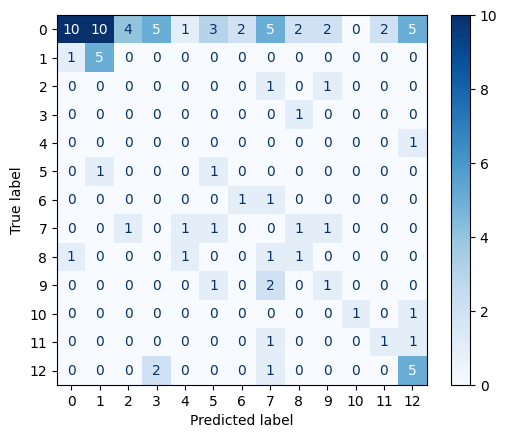

In [25]:
evaluate_model(model, device, test_loader)